## 3.8 양자 생성 적대적 신경망 (Quantum GAN)

In [1]:
# 라이브러리 불러오기
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit_algorithms.optimizers import COBYLA

In [2]:
# 양자 생성자 정의
def generator_circuit(params):
    qc = QuantumCircuit(1, 1)
    qc.ry(params[0], 0)
    return qc

In [3]:
# 양자 판별자 정의
def discriminator_circuit():
    qc = QuantumCircuit(1, 1)
    qc.measure(0, 0)
    return qc

In [4]:
# 시뮬레이터 생성
simulator = AerSimulator()

In [5]:
# 생성자의 비용함수 정의
def generator_cost(params):
    qc = generator_circuit(params)
    qc.compose(discriminator_circuit(), inplace=True)
    transpiled_qc = transpile(qc, simulator)
    result = simulator.run(transpiled_qc).result()
    counts = result.get_counts()
    probability_of_one = counts.get('1', 0) / sum(counts.values())
    return 1 - probability_of_one

In [6]:
# 파라미터 초기화
initial_params = np.random.rand(1) * 2 * np.pi

In [7]:
# 생성자 파라미터 최적화
optimizer = COBYLA(maxiter=100)
result = optimizer.minimize(generator_cost, initial_params)

In [8]:
# 최적화된 파라미터 출력
print("Optimized parameters:", result.x)

Optimized parameters: [3.07653201]


In [9]:
# 최종 생성자 회로
optimized_qc = generator_circuit(result.x)
print(optimized_qc) 

     ┌────────────┐
  q: ┤ Ry(3.0765) ├
     └────────────┘
c: 1/══════════════
                   


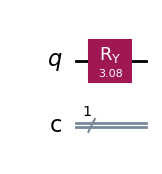

In [10]:
# 최종 생성자 회로 시각화
optimized_qc.draw('mpl')